In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

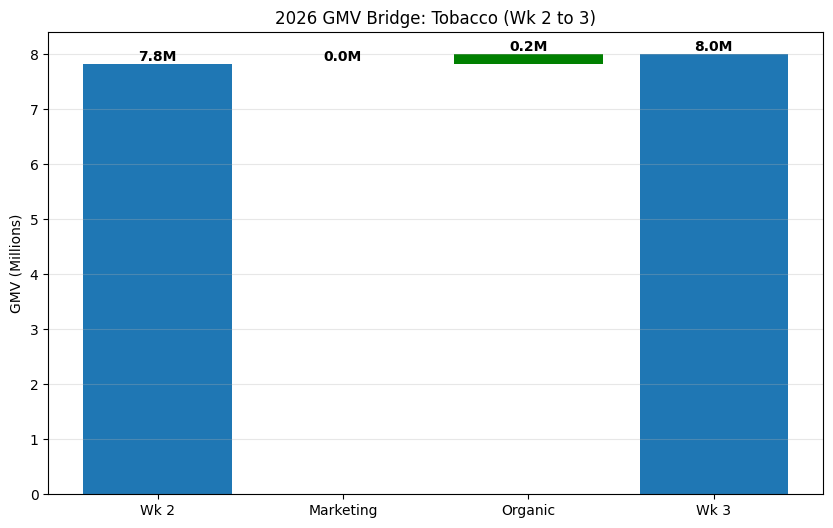

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def generate_waterfall(file_path, category, week_start, week_end):
    # 1. Load data
    df = pd.read_csv(file_path)
    
    # Clean numbers (Fixing the 'E' notation)
    for col in ['weekly_gmv', 'marketing_spend']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0) / 1e6
    df['weekly_ROI'] = pd.to_numeric(df['weekly_ROI'], errors='coerce').fillna(0)
    
    # 2. Filter for your category
    data = df[df['analytic_category'] == category].sort_values('week_num')
    
    # 3. Get the two weeks we want to compare
    try:
        # ✅ FIX: iloc uses SQUARE brackets []
        base = data[data['week_num'] == week_start].iloc[0]
        current = data[data['week_num'] == week_end].iloc[0]
    except IndexError:
        print(f"❌ Error: Data missing for {category} in Week {week_start} or {week_end}")
        return

    # 4. MMM Waterfall Math
    total_delta = current['weekly_gmv'] - base['weekly_gmv']
    spend_change = current['marketing_spend'] - base['marketing_spend']
    mkt_impact = spend_change * base['weekly_ROI']
    # Organic is whatever is left over
    organic = total_delta - mkt_impact

    # 5. Prepare the Plot
    labels = [f'Wk {week_start}', 'Marketing', 'Organic', f'Wk {week_end}']
    amounts = [base['weekly_gmv'], mkt_impact, organic, current['weekly_gmv']]
    
    # ✅ FIX: Calculate starting heights (bottoms) for the floating bars
    bottoms = [0, base['weekly_gmv'], base['weekly_gmv'] + mkt_impact, 0]

    colors = ['tab:blue', 
              'green' if mkt_impact >= 0 else 'red', 
              'green' if organic >= 0 else 'red', 
              'tab:blue']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # ✅ FIX: Use 'bottom' (singular) and 'color' (singular)
    bars = ax.bar(labels, amounts, bottom=bottoms, color=colors)

    # 6. Add the "M" labels on top of bars
    for i, bar in enumerate(bars):
        val = bar.get_height() # ✅ FIX: get_height() not get_heights()
        y_pos = bottoms[i] + val if val >= 0 else bottoms[i] + val
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:.1f}M', 
                ha='center', va='bottom' if val >= 0 else 'top', fontweight='bold')

    # ✅ FIX: Ensure these are NOT indented (they must be outside the loop)
    ax.set_title(f'2026 GMV Bridge: {category} (Wk {week_start} to {week_end})')
    ax.set_ylabel('GMV (Millions)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()


path = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML\Water_fall.csv"
generate_waterfall(path, 'Tobacco', 2, 3)

In [130]:
for name in df['analytic_category'].unique():
    print(name)
    

AirConditioner
AppliancePass
AppliancesValueAddedService
AutoAccessory
AutomationAndRoboticsIOT
AutomationAndRoboticsSHA
BabyCareOthers
BabyCareSupply
BabyGear
Bags
Bathroom
BathroomAndCleaning
BedRoomLF
BedRoomSF
Bedroom
BikeEssential
Book
BroadbandPostpaidBP
Camera
CameraAccessory
CarAVElectronicsAndAccessories
CarAndBikeBreakdownEquipment
CarAndBikeCare
CarAndBikeLighting
CarAndBikeStyling
CarEssential
Coins
ComputerAccessory
ComputerPeripheral
CookingAndCookware
Core
CreditCardBP
Curtain
DesktopPC
DiaperAndNappies
Digital
DigitalGiftVoucher
DigitalSubscription
DigitalVoucherCode
Dining&KitchenLF
Dining&KitchenSF
DiningAndStorage
Dishwasher
Donation
DthRecharge
ElectricalHardware
ElectricityBP
EntertainmentSmall
ExerciseAndFitness
ExtendedWarrantyNew
EyeWear
FashionJewellery
FastagRecharge
FestiveAndGifting
FittingsAndFixtures
FlipkartPackagingMaterial
Flooring
FourWheeler
Fragrance
GameCDDVD
Gaming
GamingHardwareGaming
GamingHardwareITAcc
GasBP
GemStone
GeneralUtilityFurnitureLF
Ge